In [ ]:
import numpy as np
from scipy.stats import wasserstein_distance_nd
from scipy.spatial import procrustes
import ot
from decoding_core import utils
from decoding_core.shape_metrics import *

# Distances between Volta vs Pretrained Dynamix vs Finetuned Dynamix on Neroephinephrine

In [3]:
labels = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_02__RIGINM__NE__155Vs_10Hz__ALC2_INM001_02bW02R01M/NE/labels.npy')
combined_activations = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_02__RIGINM__NE__155Vs_10Hz__ALC2_INM001_02bW02R01M/NE/combined_3d.npy')
combined_act_fine = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_02__RIGINM__NE__155Vs_10Hz__ALC2_INM001_02bW02R01M/NE/combined_fine_tune_0.npy')
combined_act_fine2 = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_02__RIGINM__NE__155Vs_10Hz__ALC2_INM001_02bW02R01M/NE/combined_fine_tune_2_epoch50.npy')
labels = np.mean(labels.reshape(35,150,-1), axis=1)
combined_activations = np.mean(combined_activations, axis=1)
combined_act_fine = np.mean(combined_act_fine, axis=1)
combined_act_fine2 = np.mean(combined_act_fine2, axis=1)
activations = combined_activations[:,:, :10]
act_fine = combined_act_fine[:,:, :10]
act_fine2 = combined_act_fine2[:,:, :10]
print(f'labels shape: {labels.shape}')
print(f'combined activations shape: {combined_activations.shape}')
print(f'combined fine tuned activations shape: {combined_act_fine2.shape}')
print(f'activations shape: {activations.shape}')
print(f'fine tuned activations shape: {act_fine2.shape}')

labels shape: (35, 4)
combined activations shape: (35, 1000, 11)
combined fine tuned activations shape: (35, 1000, 11)
activations shape: (35, 1000, 10)
fine tuned activations shape: (35, 1000, 10)


In [4]:
A_act = std_global(combined_activations[:, :, :10])
A_vol = std_global(combined_activations[:, :, 10:11])
A_act_fine = std_global(combined_act_fine[:, :, :10])
A_act_fine2 = std_global(combined_act_fine2[:, :, :10])

In [5]:
D_act, D_vol, D_act_f, D_act_f2 = w2_matrix(A_act), w2_matrix(A_vol),w2_matrix(A_act_fine), w2_matrix(A_act_fine2)

In [6]:
D_proc_act, D_proc_vol = procrustes_matrix(A_act), procrustes_matrix(A_vol)

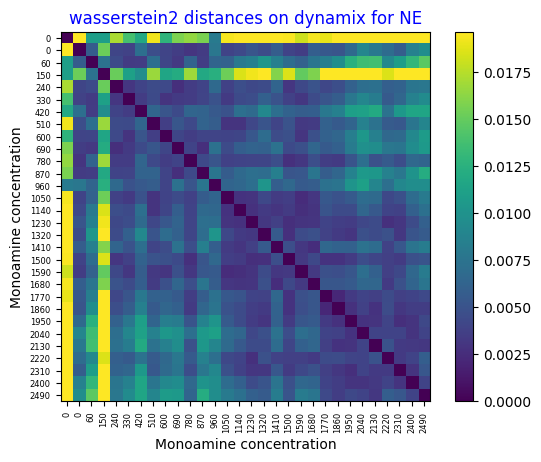

In [7]:

import matplotlib.pyplot as plt

Y=labels
pure = np.where((Y[:,0]==0)&(Y[:,1]==0))[0]
o = pure[np.argsort(Y[pure,2])]
Dp = D_act[np.ix_(o,o)]
plt.title('wasserstein2 distances on dynamix for NE', color='blue')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()


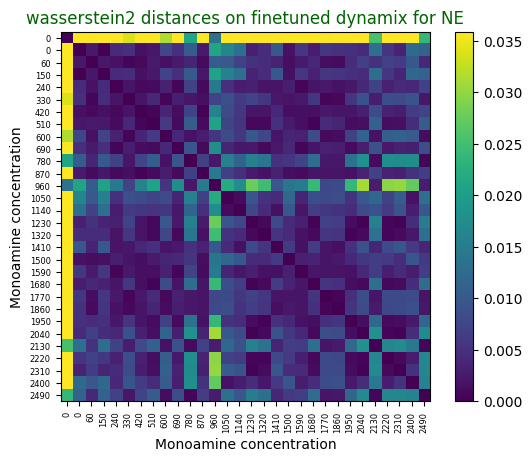

In [8]:
Dp = D_act_f[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned dynamix for NE', color = 'darkgreen')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))

plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()

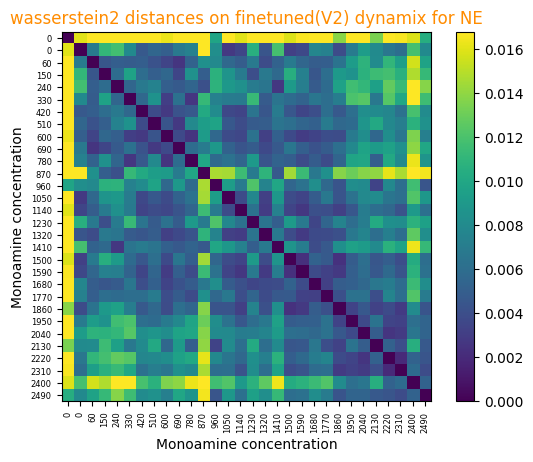

In [9]:
Dp = D_act_f2[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned(V2) dynamix for NE', color = 'darkorange')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))

plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()

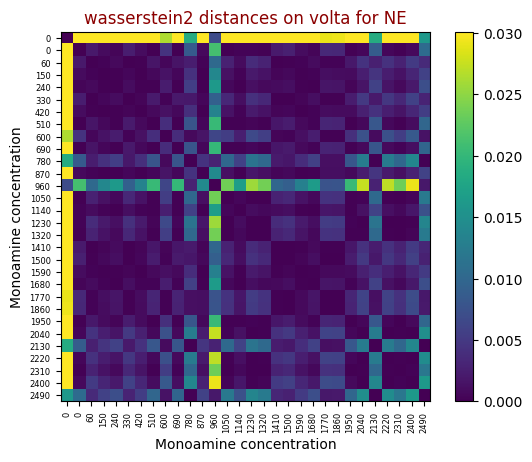

In [10]:
Dp = D_vol[np.ix_(o,o)]
plt.title('wasserstein2 distances on volta for NE', color='darkred')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))

plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()

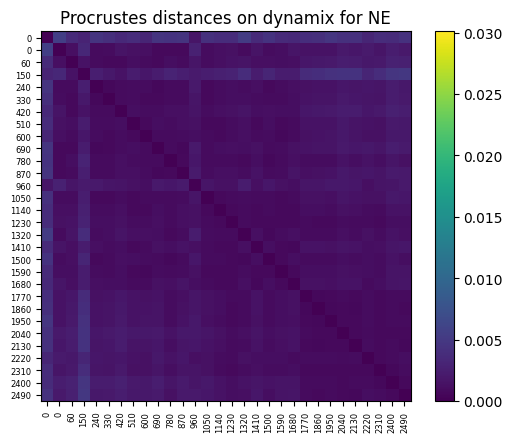

In [11]:
D_proc_p = D_proc_act[np.ix_(o,o)]
plt.title('Procrustes distances on dynamix for NE')
plt.imshow(D_proc_p, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()

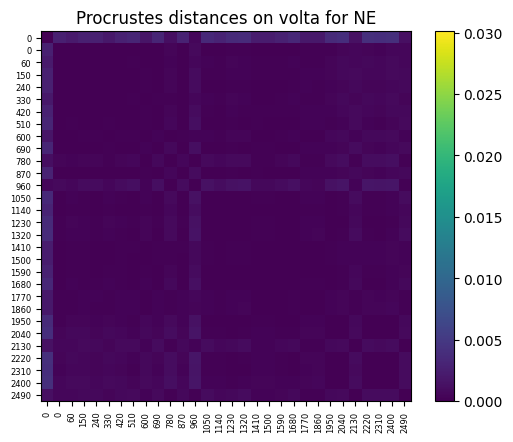

In [12]:
D_proc_p = D_proc_vol[np.ix_(o,o)]
plt.title('Procrustes distances on volta for NE')
plt.imshow(D_proc_p, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,2].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,2].astype(int), fontsize=6)
plt.colorbar()

# Distances between Volta vs Pretrained Dynamix vs Finetuned Dynamix on Seratonin 

In [13]:
labels_seratonin = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_01__RIGINM__5HT__155Vs_10Hz__ALC2_INM001_02bW02R01M/5HT/labels.npy')
combined_activations_seratonin = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_01__RIGINM__5HT__155Vs_10Hz__ALC2_INM001_02bW02R01M/5HT/combined_3d.npy')
combined_act_fine_seratonin2 = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_01__RIGINM__5HT__155Vs_10Hz__ALC2_INM001_02bW02R01M/5HT/combined_fine_tune_2_epoch50.npy')
combined_act_fine_seratonin = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_10_01__RIGINM__5HT__155Vs_10Hz__ALC2_INM001_02bW02R01M/5HT/combined_fine_tune_0.npy')
labels_seratonin = np.mean(labels_seratonin.reshape(35,150,-1), axis=1)
combined_activations_seratonin = np.mean(combined_activations_seratonin, axis=1)
combined_act_fine_seratonin = np.mean(combined_act_fine_seratonin, axis=1)
combined_act_fine_seratonin2 = np.mean(combined_act_fine_seratonin2, axis=1)
activations_seratonin = combined_activations_seratonin[:,:, :10]
act_fine_seratonin = combined_act_fine_seratonin[:,:, :10]
act_fine_seratonin2 = combined_act_fine_seratonin2[:,:, :10]

In [14]:
A_act_seratonin = std_global(combined_activations_seratonin[:, :, :10])
A_vol_seratonin = std_global(combined_activations_seratonin[:, :, 10:11])
A_act_fine_seratonin = std_global(combined_act_fine_seratonin[:, :, :10])
A_act_fine_seratonin2 = std_global(combined_act_fine_seratonin2[:, :, :10])

In [15]:
D_act_seratonin, D_vol_seratonin, D_act_fine_seratonin, D_act_fine_seratonin2 = w2_matrix(A_act_seratonin), w2_matrix(A_vol_seratonin), w2_matrix(A_act_fine_seratonin),w2_matrix(A_act_fine_seratonin2)

In [16]:
D_proc_act_seratonin, D_proc_vol_seratonin = procrustes_matrix(A_act_seratonin), procrustes_matrix(A_vol_seratonin)

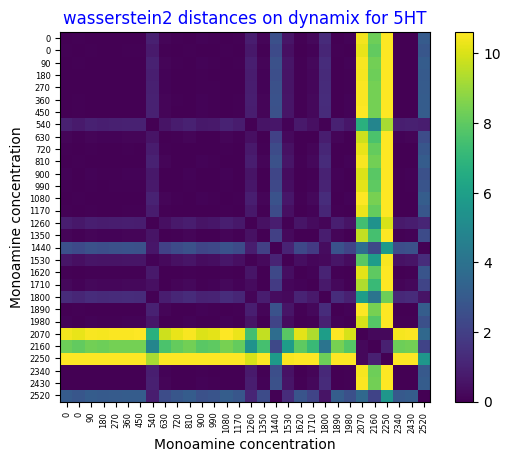

In [34]:

Y=labels_seratonin
pure = np.where((Y[:,0]==0)&(Y[:,2]==0))[0]
o = pure[np.argsort(Y[pure,1])]
Dp = D_act_seratonin[np.ix_(o,o)]
plt.title('wasserstein2 distances on dynamix for 5HT', color='blue')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)

plt.colorbar()


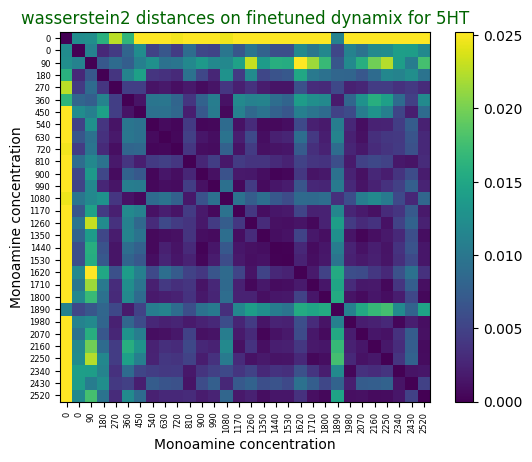

In [35]:
Dp = D_act_fine_seratonin[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned dynamix for 5HT', color='darkgreen')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)
plt.colorbar()

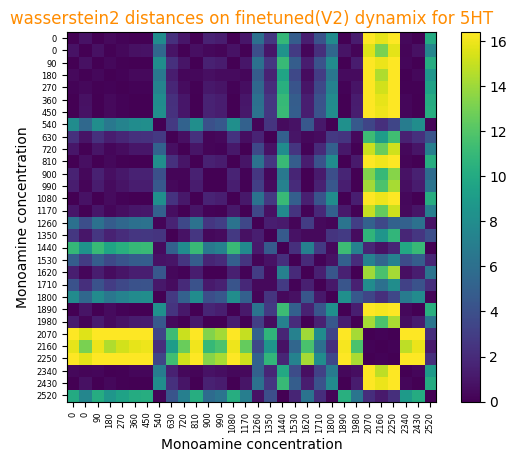

In [36]:
Dp = D_act_fine_seratonin2[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned(V2) dynamix for 5HT', color='darkorange')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)
plt.colorbar()

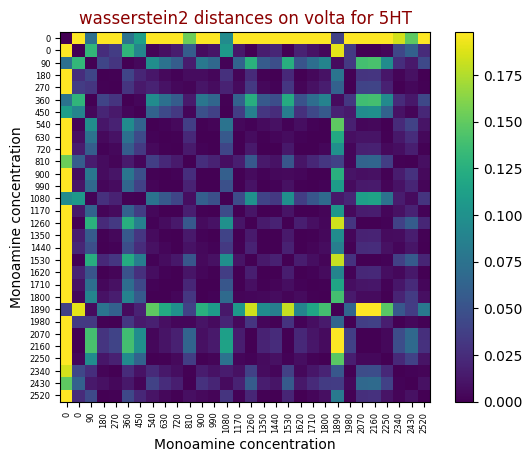

In [37]:
Dp = D_vol_seratonin[np.ix_(o,o)]
plt.title('wasserstein2 distances on volta for 5HT', color='darkred')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)
plt.colorbar()

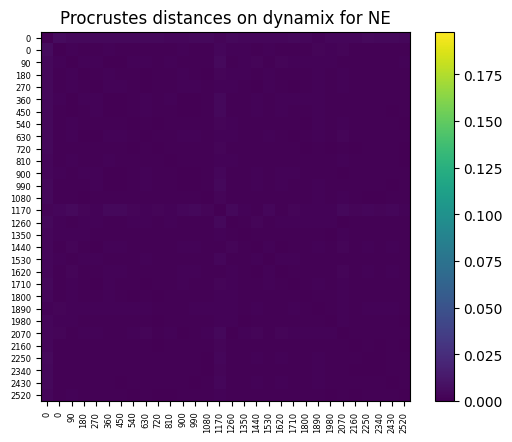

In [21]:
D_proc_p = D_proc_act[np.ix_(o,o)]
plt.title('Procrustes distances on dynamix for NE')
plt.imshow(D_proc_p, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)
plt.colorbar()

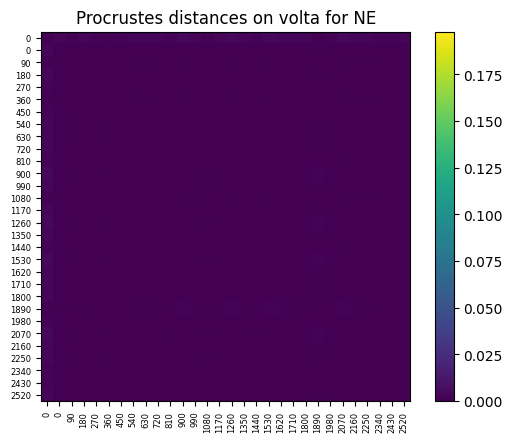

In [22]:
D_proc_p = D_proc_vol[np.ix_(o,o)]
plt.title('Procrustes distances on volta for NE')
plt.imshow(D_proc_p, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,1].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,1].astype(int), fontsize=6)
plt.colorbar()

# Distances between Volta vs Pretrained Dynamix vs Finetuned Dynamix on Dopamine 

In [23]:
labels_da = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC2_INM001_02bW02R01M/DA/labels.npy')
combined_activations_da = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC2_INM001_02bW02R01M/DA/combined_3d.npy')
combined_act_fine_da2 = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC2_INM001_02bW02R01M/DA/combined_fine_tune_2_epoch50.npy')
combined_act_fine_da = np.load('/home/sgurbuz/nasShare/projects/sgurbuz/dynamix_tryout/data_1d_vxlbl/ALCIS_155_macroREF/alc2/155Vs/10Hz/2025_09_30__RIGINM__DA__155Vs_10Hz__ALC2_INM001_02bW02R01M/DA/combined_fine_tune_0.npy')
labels_da = np.mean(labels_da.reshape(35,150,-1), axis=1)
combined_activations_da = np.mean(combined_activations_da, axis=1)
combined_act_fine_da = np.mean(combined_act_fine_da, axis=1)
combined_act_fine_da2 = np.mean(combined_act_fine_da2, axis=1)
activations_da = combined_activations_da[:,:, :10]
act_fine_da = combined_act_fine_da[:,:, :10]
act_fine_da2 = combined_act_fine_da2[:,:, :10]

In [24]:
A_act_da = std_global(combined_activations_da[:, :, :10])
A_vol_da = std_global(combined_activations_da[:, :, 10:11])
A_act_fine_da = std_global(combined_act_fine_da[:, :, :10])
A_act_fine_da2 = std_global(combined_act_fine_da2[:, :, :10])

In [25]:
D_act_da, D_vol_da, D_act_fine_da, D_act_fine_da2 = w2_matrix(A_act_da), w2_matrix(A_vol_da), w2_matrix(A_act_fine_da),w2_matrix(A_act_fine_da2)

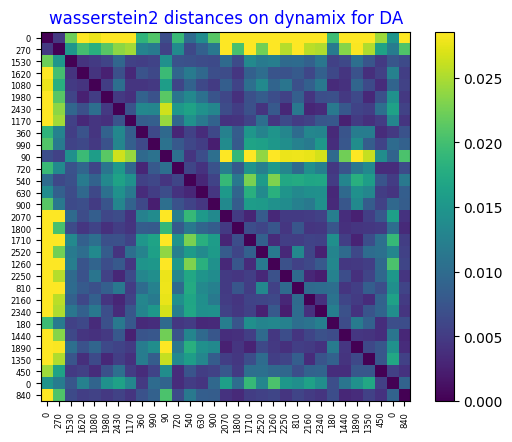

In [26]:

Y=labels_da
pure = np.where((Y[:,1]==0)&(Y[:,1]==0))[0]
o = pure[np.argsort(Y[pure,1])]
Dp = D_act_da[np.ix_(o,o)]
plt.title('wasserstein2 distances on dynamix for DA', color='blue')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,0].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,0].astype(int), fontsize=6)
plt.colorbar()


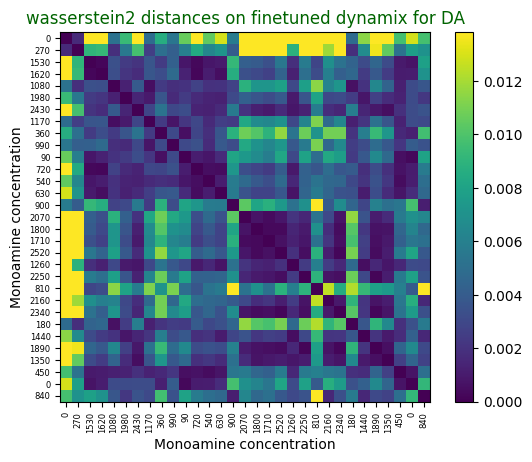

In [27]:
Dp = D_act_fine_da[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned dynamix for DA', color='darkgreen')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,0].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,0].astype(int), fontsize=6)
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.colorbar()

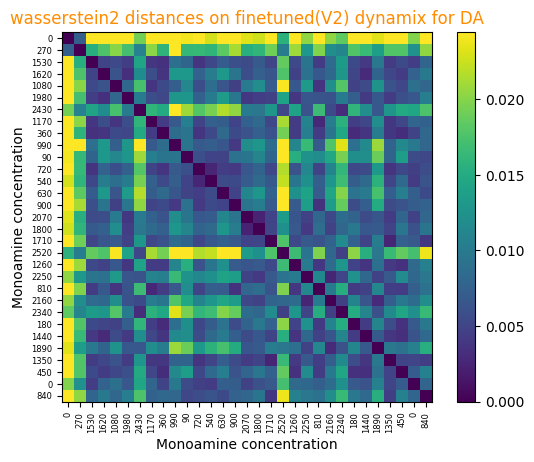

In [28]:
Dp = D_act_fine_da2[np.ix_(o,o)]
plt.title('wasserstein2 distances on finetuned(V2) dynamix for DA', color='darkorange')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,0].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,0].astype(int), fontsize=6)
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.colorbar()

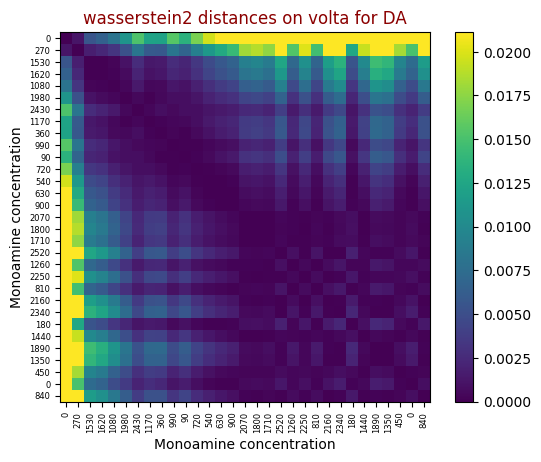

In [29]:
Dp = D_vol_da[np.ix_(o,o)]
plt.title('wasserstein2 distances on volta for DA', color='darkred')
plt.imshow(Dp, cmap="viridis", vmin=0, vmax=np.percentile(Dp[np.triu_indices(len(o),1)],95))
plt.xticks(range(len(o)), Y[o,0].astype(int), rotation=90, fontsize=6)
plt.yticks(range(len(o)), Y[o,0].astype(int), fontsize=6)
plt.xlabel('Monoamine concentration')
plt.ylabel('Monoamine concentration')
plt.colorbar()